## Module_3: *

## Team Members:
Delaney Broderick, Priya Shan 

## Analyzing the Extent of Fibrosis at Different Lung Depths 



## Project Goal:
This project seeks to analyze a lung biopsy device developed by Intuitive, a medical device company by developing an analysis pipeline to predict the extent of fibrosis in the lung at different biopsy depths from the top of the lung. 

## Disease Background: 

* Prevalence & incidence: Prevalence per 100000 was 17.7 globally. Incidence per 100000 5.8 globally. 
https://link.springer.com/article/10.1186/s12890-025-03836-1 

* Risk factors (genetic, lifestyle)- males are more at risk, old age, tobacco smoking, family history of IPF, and mutations in genes such as MUC5B and TERT
https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis/causes

* Symptoms - crackling sound in the lungs, difficulty breathing, fatigue, and a persistent dry cough.

*Diagnosis- The diagnosis of IPF is made using many different tests and factors. One aspect that must be present for the diagnosis of IPF is bilateral (both sides of lung) fibrosis. This can be seen in either a chest xray or chest CT scan. These fibrosis must have unexplained patterns in order to be classified as idiopathic. Family history of IPF, an age over 60 years, and inspiratory crackles are also considered in dianosis as these are risk factors/ classic symptoms. Biopsies are sometimes used to make the diagnosis, however it is not required and not always beneficial. 
https://www.thoracic.org/statements/resources/interstitial-lung-disease/diagnosis-IPF-full-length.pdf

* Standard of care treatment(s) - currently no cure besides a lung transplant. Other treatments are supplemental oxygen, pulmonary rehabilitation, different anti-fibrotic medications that can slow the disease progression. 

*Disease Progression and Prognosis- The average survival time for patients with IPF who do not receive anti-fibrotic treatment is typically between 2.5 and 3.5 years. The rate of surviving 5 years after diagnosis is between 20-30%. The disease progresses to cause decreased lung capacity, worsening trouble breathing, and increased fibrosis in imaging. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC10540722/

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) - Fibrosis is the accumulation of scar tissue. In IPF it takes place in the lungs and is irreversible. The myofibroblasts overproliferate and produce escessive collagen. The myofibroblasts also do not undergo apoptosis (cell death) properly and so they accumulate. The excess collagen that builds up leads to loss of alveoli. The loss of alvioli causes fluid-filled spaces to be created. IPF causes a decrease in total lung capacity (maximum amount of air the lungs can hold) and decrease in the forced vital capacity. 

-The provided informational videos were used to fill out this section unless otherwise noted. 

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 

General Overview: Given the sample data set of images of the cross section of the lung, we analyzed the extent of fibrosis in each image. We did this by importing the images with grayscale and diving the number of white pixels by the number of black pixels. In addition, since images of the lung are not provided at each depth, we develped an algorithm to interpolate the amount of fibrosis at a specific depth, based on the provided sample data set. 

### 1. Quantifying Images of the Lung for Analysis 

This provides the foundation to analyze the extent of fibrosis at different depths in the lung. Here we follow the principle that white regions in images represent fibrotic lesions and black regions represent the healthy lung. 

In [5]:
#Importing Necessary Libraries for Analysis 

from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

In [6]:
# Load the images you want to analyze
#The total length of a mouse lung is around 10,000 micrometers. 
#Thus, we chose to analyze 20 images at around equal intervals apart within the lung
filenames = [
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010039.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010032.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010066.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010067.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010146.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010143.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010147.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010149.jpg", 
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010065.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010134.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010110.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010112.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010168.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010034.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010130.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010149.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010119.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010146.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010121.jpg",
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010135.jpg", 
    r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010098.jpg"

]

# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [
    15, 500, 1000, 1500, 2000, 2600, 3000, 3350, 3900, 4500,
    5300, 5500, 6000, 6600, 7000, 7500, 8000, 8500, 9000, 9500, 10000
]

In [7]:
# Results storage
results = []

# Single loop for all logic
for file, depth in zip(filenames, depths):
    #read in the image in grayscale 
    img = cv2.imread(file, 0)
    
    if img is None:
        print(colored(f"Warning: Could not load {file}", "red"))
        continue

    # Use a binary threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Vectorized counting
    white_count = np.count_nonzero(binary)  # Faster than np.sum(binary == 255)
    total_pixels = binary.size
    black_count = total_pixels - white_count
    #determine the percentage of white pixels in the image
    white_percent = (white_count / total_pixels) * 100

    # Print results as a check point 
    #print(colored(f"File: {file}", "red"))
    #print(f"White: {white_count} | Black: {black_count}")
    #print(f"Fibrosis: {white_percent:.2f}% | Depth: {depth} microns\n")

    # Store data for CSV
    results.append({
        'Filenames': file,
        'Depths': depth,
        'White Counts': white_count,
        'White percents': white_percent
    })

### Results from the Image Analysis 

In [8]:
# Create DataFrame and Export results to a csv 
df = pd.DataFrame(results)
df.to_csv('Percent_White_Pixels.csv', index=False)

print(colored("Success: 'Percent_White_Pixels.csv' created.", "green"))

print("The .csv file 'Percent_White_Pixels.csv' has been created.")
#print the first few rows of the dataframe to check that it looks correct
print(df.head())

Success: 'Percent_White_Pixels.csv' created.
The .csv file 'Percent_White_Pixels.csv' has been created.
                                           Filenames  Depths  White Counts  \
0  /Users/priya/Documents/Comp_Bio/GitHub/Module-...      15         21648   
1  /Users/priya/Documents/Comp_Bio/GitHub/Module-...     500         48667   
2  /Users/priya/Documents/Comp_Bio/GitHub/Module-...    1000         60715   
3  /Users/priya/Documents/Comp_Bio/GitHub/Module-...    1500         62508   
4  /Users/priya/Documents/Comp_Bio/GitHub/Module-...    2000         62913   

   White percents  
0        0.516129  
1        1.160312  
2        1.447558  
3        1.490307  
4        1.499963  


### 2. Interpolating Extent of Fibrosis at Different Depths 

In [15]:
# Linear interpolation of data 
interpolate_depth = float(input(colored(
     "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = [item['White percents'] for item in results]

# # You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
   f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = [item['White percents'] for item in results]
white_percents_i.append(interpolate_point)

The interpolated point is at the x-coordinate 8330.0 and y-coordinate 3.4100632667541504.


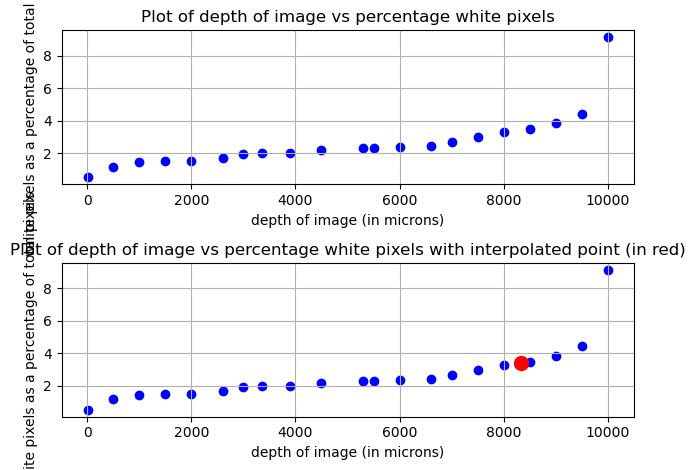

In [18]:
#Plot the results from linear interpolation 
# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, [item['White percents'] for item in results], marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
   'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [22]:
# Linear interpolation of data 
interpolate_depth = float(input(colored(
     "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = [item['White percents'] for item in results]

# # You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
   f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = [item['White percents'] for item in results]
white_percents_i.append(interpolate_point)

The interpolated point is at the x-coordinate 8330.0 and y-coordinate 3.394748408646257.


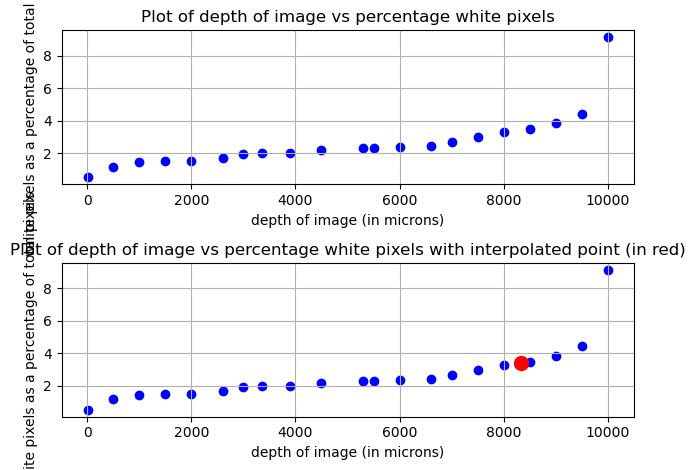

In [23]:
#Plot the results from linear interpolation 
# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, [item['White percents'] for item in results], marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
   'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Verify and validate analysis: 

### Verification 

In the analysis section, we ran two different types of interpolation: linear and quadratic. For the linear interpolation at 8300 micrometers, it was determined that the percent fibrosis was 3.41%. Similarly, for the quadratic interpolation at 8300 micrometers, the percent fibrosis was calculated to be 3.39%. Considering that the extent of fibrosis was 3.28% and 3.48% at 8000 micrometers and 8500 micrometers from the dataset, the interpolation results fits with the idea that fibrosis increases as lung depth increases. Thus, the estimated values make sense compared to the other data points from the sample. 

### Validation

There is an image in the dataset recorded at 8300 micrometers lung depth. Thus, we used this image to validate our results from interpolation at the same lung depth. 

In [12]:
#Analyze percent white pixels from the image in the dataset at 8300 micrometers lung depth
filename = r"/Users/priya/Documents/Comp_Bio/GitHub/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010140.jpg"
depth = 8300
#Utilizing the same code as above without the for loop to analyze only one image 
img = cv2.imread(filename, 0)

if img is None:
    print(colored(f"Error: Could not find image at {filename}", "red"))
else:
    # Apply threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # 3. Calculate metrics
    white_count = np.count_nonzero(binary)
    total_pixels = binary.size
    black_count = total_pixels - white_count
    white_percent = (white_count / total_pixels) * 100

    # 4. Print Results
    #print(colored(f"File: {filename}", "red"))
    print(f"Percent White: {white_percent:.4f}%")

Percent White: 3.3335%


### Percent Error 

Linear Interpolation: (3.41 - 3.33 / 3.33) * 100% = 2.4%

Quadratic Interpolation: (3.39 - 3.33 / 3.33) * 100% = 1.8% 

Overall, both types of interpolation had lower percent errors compared to the actual extent of fibrosis at 8300 micrometers. Although, the quadratic interpolation does have a lower percent error. This goes to validate our results from interpolation and also confirm that adding another point while interpolating increases accuracy. 

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

From our analysis and interpolation of the mouse model of lung fibrotic disease, we can draw the conclusion that the extent of fibrosis increases as lung depth increases. This crucial finding is important to keep in consideration while building the final lung biopsy medical device. The two different types of interpolation were both very accurate, which is supported by the low percent errors (2.4% for linear and 1.8% for quadratic). These interpolation algorithms successfully estimate the fibrosis levels at depths where imaging is difficult. While the errors of our algorithm is very low, there is still a risk of either over diagnosis or under diagnosis due to the lack of human oversight. Doctors take in many aspects to make a diagnosis beyond just this biopsy. They use symptoms, risk factors, and patient history to make a diagnosis. Our algorithm is pretty accurate at interpolating the biopsy, but it does not use any other information to make the diagnosis. An aspect where this model is more ethical than the use of humans making diagnosises is that the algorithm does not have an bias or discrimination towards different races, genders, and ages. This is an important area where using an algorithm is very beneficial, especially for marginalized communities. 

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

Due to our interpolation being very accurate and being able to estimate fibrosis levels at depths were imaging is very difficult, it would be useful to continue to develop the algorithm and use this method to estimate fibrosis levels at depths difficult to visualize. This could help make diagnosis of fibrosis easier and less invasive, while still getting the needed visualization of the tissue's condition. The current algorithm was made using a sample size of images from mouse models. In the future, it would be extremely beneficial to expand the sample size to expand what the algorithm can interpolate for. We could also try to extrapolate past the given depths to gain additional information without imaging. It would also be important to make sure the accuracy of our interpolation holds up when using human images instead of mice. Making sure that the algorithm accurately reads a larger group of human images would be essential before using the algorithm more widely. 

## References:
https://link.springer.com/article/10.1186/s12890-025-03836-1 
https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis/causes
https://www.youtube.com/watch?v=s2owdwl5Vac
https://www.youtube.com/watch?v=Z6_0WkceY88
https://www.facebook.com/PFFORG/videos/1042168686536691/
https://www.thoracic.org/statements/resources/interstitial-lung-disease/diagnosis-IPF-full-length.pdf
https://pmc.ncbi.nlm.nih.gov/articles/PMC10540722/
